<a href="https://colab.research.google.com/github/fernandocosta-gcp/ace-module2-lab/blob/main/futebol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cdlib

In [2]:
# Instala a biblioteca CDlib e suas dependências necessárias no Colab
!pip install cdlib pyintergraph --quiet

import urllib.request
import networkx as nx
import matplotlib.pyplot as plt
from cdlib import algorithms, viz

# URL do arquivo GML
url = "https://static.plataforma.grupoa.education/pucpr/111/66256/c5ccd3fa-2678-4836-b16e-842aff278c1b.gml"

# Baixar o conteúdo do arquivo GML
response = urllib.request.urlopen(url)
gml_data = response.read().decode('utf-8')

# Carregar o grafo na memória usando NetworkX
G = nx.parse_gml(gml_data)

print(f"Grafo carregado com sucesso!")
print(f"Número de nós: {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.3/314.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.8 MB/s eta 0:00:00
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'leidenalg', 'graph_tool', 'wurlitzer', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw', 'hidef'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap', 'leidenalg', 'scikit-network'}
Grafo carregado com sucesso!
Número de nós: 115
Número de arestas: 613


In [3]:
# O grafo G já foi carregado a partir do GML.
# Aqui garantimos que G está instanciado e pronto para uso.
G = nx.parse_gml(gml_data)

# Exibe algumas informações estruturais do grafo G
print(f"Grafo G instanciado!")
print(f"Estrutura: {type(G)}")
print(f"Nós: {len(G.nodes)}")
print(f"Arestas: {len(G.edges)}")

Grafo G instanciado!
Estrutura: <class 'networkx.classes.graph.Graph'>
Nós: 115
Arestas: 613


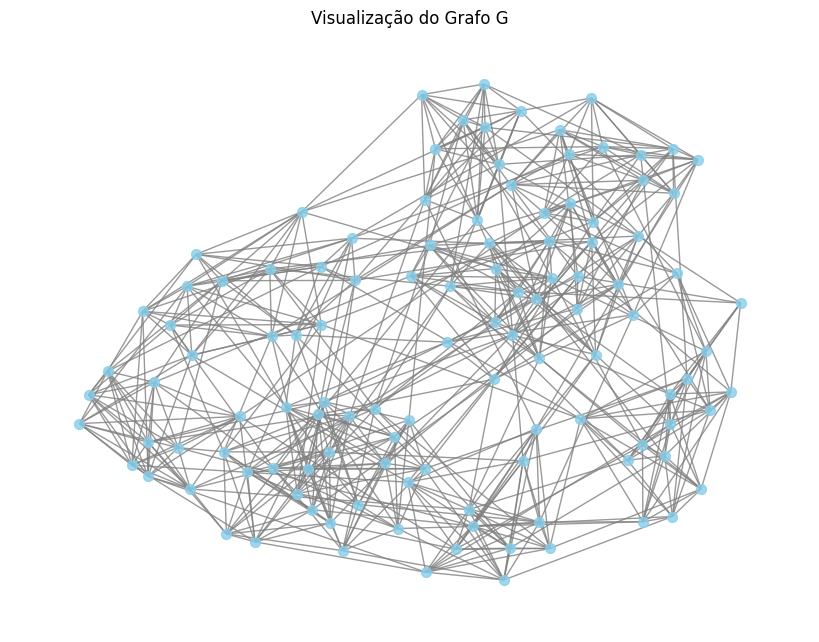

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# Define o tamanho da figura para 8 x 6
plt.figure(figsize=(8, 6))

# Define um layout para posicionar os nós (ex: spring_layout)
pos = nx.spring_layout(G, seed=42)

# Desenha o grafo G
nx.draw(G, pos, with_labels=False, node_size=50, node_color="skyblue", edge_color="gray", alpha=0.8)

# Título e exibição
plt.title("Visualização do Grafo G")
plt.show()

In [5]:
# Detecção de comunidades usando o algoritmo de Girvan-Newman da CDlib
# O parâmetro 'level=6' define o nível de corte dendrogramático
communities = algorithms.girvan_newman(G, level=6)

# Exibe informações sobre as comunidades encontradas
print(f"Algoritmo: {communities.method_name}")
print(f"Quantidade de comunidades detectadas: {len(communities.communities)}")
for idx, community in enumerate(communities.communities):
    print(f"Comunidade {idx + 1} (Tamanho {len(community)}): {community}")

Algoritmo: Girvan Newman
Quantidade de comunidades detectadas: 7
Comunidade 1 (Tamanho 25): ['Florida', 'Auburn', 'Tennessee', 'Alabama', 'Houston', 'Vanderbilt', 'EastCarolina', 'Mississippi', 'SouthernMississippi', 'Tulane', 'LouisianaLafayette', 'Louisville', 'Memphis', 'AlabamaBirmingham', 'SouthCarolina', 'MiddleTennesseeState', 'Georgia', 'LouisianaState', 'Kentucky', 'LouisianaMonroe', 'MississippiState', 'Army', 'LouisianaTech', 'Cincinnati', 'Arkansas']
Comunidade 2 (Tamanho 24): ['SouthernCalifornia', 'Arizona', 'BrighamYoung', 'Idaho', 'Stanford', 'Washington', 'Oregon', 'Utah', 'OregonState', 'AirForce', 'Wyoming', 'NewMexicoState', 'UCLA', 'ArkansasState', 'California', 'WashingtonState', 'SanDiegoState', 'NorthTexas', 'UtahState', 'NevadaLasVegas', 'ColoradoState', 'ArizonaState', 'BoiseState', 'NewMexico']
Comunidade 3 (Tamanho 18): ['NorthCarolinaState', 'FloridaState', 'WakeForest', 'Maryland', 'VirginiaTech', 'Virginia', 'GeorgiaTech', 'Clemson', 'MiamiFlorida', 'Duke

<Figure size 1000x800 with 0 Axes>

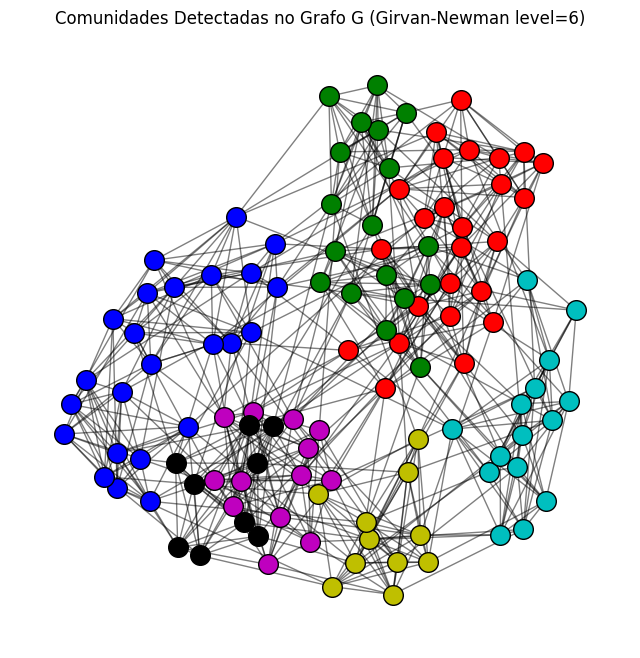

In [6]:
# Desenha o grafo colorindo os nós de acordo com as comunidades detectadas
plt.figure(figsize=(10, 8))

# Usando a função de visualização integrada da CDlib para desenhar as comunidades no grafo
viz.plot_network_clusters(G, communities, pos, node_size=60, plot_labels=False)

plt.title("Comunidades Detectadas no Grafo G (Girvan-Newman level=6)")
plt.show()